# Phase 5 — Robustness Sweeps (Scenario A)

## Purpose
This notebook tests how *stable* Scenario A trial-selection outcomes are when we vary:
- **λ_cost** (cost penalty weight)
- **λ_safety** (safety penalty weight; MAUDE-derived)
- **K** (portfolio size)

We use a fast, deterministic **greedy baseline** for sweeping many configs quickly, then:
- compute objective components (benefit / cost / safety),
- measure stability via **Jaccard overlap** vs a baseline configuration,
- export tables + figures for Phase 5 reporting.

## Inputs
From the repo:
- `data/scenarios/scenario_A_trials.csv` (scenario trials + engineered features)

## Outputs
- `data/results/05a_robustness_sweep_summary.csv`
- `data/results/05a_robustness_top_configs_selected_trials.csv`
- `outputs/figures/05a_objective_heatmap.png`
- `outputs/figures/05a_jaccard_vs_baseline.png`


In [1]:
# ============================================================
# Cell 1 — Setup: imports, paths, and output directories
# ============================================================

from pathlib import Path
import itertools
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SCENARIO_TRIALS_PATH = Path("data/scenarios/scenario_A_trials.csv")

RESULTS_DIR = Path("data/results")
FIG_DIR = Path("outputs/figures")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not SCENARIO_TRIALS_PATH.exists():
    raise FileNotFoundError(f"Missing: {SCENARIO_TRIALS_PATH}")

print("OK: Phase 5 sweep notebook initialized.")
print("Scenario A trials:", SCENARIO_TRIALS_PATH.resolve())


OK: Phase 5 sweep notebook initialized.
Scenario A trials: /home/parallels/projects/quantum-clinical-trial-optimization/data/scenarios/scenario_A_trials.csv


### What Cell 1 Just Did

We initialized the Phase 5 robustness notebook by importing the required libraries, defining the Scenario A input file, and creating output directories for results and figures. We also validate that `scenario_A_trials.csv` exists up front so missing inputs are caught immediately.


In [2]:
# ============================================================
# Cell 2 — Load Scenario A trials and standardize feature columns
# ============================================================

dfA = pd.read_csv(SCENARIO_TRIALS_PATH)

# Required identity column
if "nct_id" not in dfA.columns:
    raise ValueError(f"Expected 'nct_id' in scenario_A_trials.csv. Found: {list(dfA.columns)[:30]}...")

dfA["nct_id"] = dfA["nct_id"].astype(str)

# We aim to use these features if present
# - benefit_score: should be produced by earlier benefit scoring notebook
# - estimated_trial_cost: simulated cost feature
# - safety_score: MAUDE-derived safety risk proxy
# Fallbacks are handled below if any are missing.
preferred_cols = ["benefit_score", "estimated_trial_cost", "safety_score", "enrollment_feasibility_score"]
print("Columns available (sample):", [c for c in preferred_cols if c in dfA.columns])

def _coerce_numeric(col, default=0.0):
    if col not in dfA.columns:
        return pd.Series([default] * len(dfA), index=dfA.index, dtype=float)
    s = pd.to_numeric(dfA[col], errors="coerce").fillna(default).astype(float)
    return s

benefit = _coerce_numeric("benefit_score", default=np.nan)
cost    = _coerce_numeric("estimated_trial_cost", default=np.nan)
safety  = _coerce_numeric("safety_score", default=np.nan)

# Practical fallbacks if your scenario file doesn’t include one of these yet:
# - If benefit_score missing: use enrollment_feasibility_score as a weak proxy (or 1.0)
if benefit.isna().all():
    feas = _coerce_numeric("enrollment_feasibility_score", default=1.0)
    benefit = feas.copy()
    print("NOTE: benefit_score missing; using enrollment_feasibility_score as benefit proxy.")

# - If cost missing: use size_bytes proxy if present, else 1.0
if cost.isna().all():
    if "size_bytes" in dfA.columns:
        cost = pd.to_numeric(dfA["size_bytes"], errors="coerce").fillna(dfA["size_bytes"].median()).astype(float)
        print("NOTE: estimated_trial_cost missing; using size_bytes proxy for cost.")
    else:
        cost = pd.Series([1.0] * len(dfA), index=dfA.index, dtype=float)
        print("NOTE: estimated_trial_cost missing; using constant cost=1.0 proxy.")

# - If safety missing: assume neutral safety risk (0.0)
if safety.isna().all():
    safety = pd.Series([0.0] * len(dfA), index=dfA.index, dtype=float)
    print("NOTE: safety_score missing; using neutral safety=0.0 proxy.")

dfA["_benefit_raw"] = benefit.fillna(0.0)
dfA["_cost_raw"]    = cost.fillna(cost[~cost.isna()].median() if (~cost.isna()).any() else 1.0)
dfA["_safety_raw"]  = safety.fillna(0.0)

print("Loaded Scenario A trials:", dfA.shape)
dfA[["nct_id", "_benefit_raw", "_cost_raw", "_safety_raw"]].head()


Columns available (sample): ['benefit_score', 'estimated_trial_cost', 'enrollment_feasibility_score']
NOTE: safety_score missing; using neutral safety=0.0 proxy.
Loaded Scenario A trials: (16672, 16)


,nct_id,_benefit_raw,_cost_raw,_safety_raw
0,NCT00002462,0.8,4.0,0.0
1,NCT00003042,0.6,2.0,0.0
2,NCT00003641,0.8,4.0,0.0
3,NCT00005584,0.8,4.0,0.0
4,NCT00006721,0.8,4.0,0.0


### What Cell 2 Just Did

We loaded Scenario A trials and standardized the three core signals needed for robustness testing: benefit, cost, and safety. Where a preferred feature column is missing, we apply a conservative fallback (e.g., feasibility as a benefit proxy, size as a cost proxy, or neutral safety risk). This ensures the sweep logic runs reliably even as upstream feature engineering evolves.


In [3]:
# ============================================================
# Cell 3 — Normalize features + define greedy selection and scoring
# ============================================================

def minmax_norm(x: pd.Series) -> pd.Series:
    """Min-max normalize to [0,1] with safe handling for constant vectors."""
    x = x.astype(float)
    lo, hi = np.nanmin(x.values), np.nanmax(x.values)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi == lo:
        return pd.Series([0.0] * len(x), index=x.index, dtype=float)
    return (x - lo) / (hi - lo)

dfA["_benefit"] = minmax_norm(dfA["_benefit_raw"])
dfA["_cost"]    = minmax_norm(dfA["_cost_raw"])
dfA["_safety"]  = minmax_norm(dfA["_safety_raw"])

def select_greedy(df: pd.DataFrame, K: int, lambda_cost: float, lambda_safety: float) -> pd.DataFrame:
    """
    Deterministic greedy selector:
      score = benefit - lambda_cost*cost - lambda_safety*safety
    Select top-K by score.
    """
    d = df.copy()
    d["_score"] = d["_benefit"] - lambda_cost * d["_cost"] - lambda_safety * d["_safety"]
    d = d.sort_values("_score", ascending=False).head(K)
    return d

def portfolio_metrics(sel_df: pd.DataFrame, K: int, lambda_cost: float, lambda_safety: float) -> dict:
    """
    Compute raw and normalized component totals + objective value.
    Objective is based on normalized components for comparability across scales.
    """
    # Totals in raw units (useful for interpretability)
    tot_b_raw = float(sel_df["_benefit_raw"].sum())
    tot_c_raw = float(sel_df["_cost_raw"].sum())
    tot_s_raw = float(sel_df["_safety_raw"].sum())

    # Totals in normalized units (used in objective)
    tot_b = float(sel_df["_benefit"].sum())
    tot_c = float(sel_df["_cost"].sum())
    tot_s = float(sel_df["_safety"].sum())

    obj = tot_b - lambda_cost * tot_c - lambda_safety * tot_s

    return {
        "K": K,
        "lambda_cost": float(lambda_cost),
        "lambda_safety": float(lambda_safety),
        "n_selected": int(sel_df["nct_id"].nunique()),
        "benefit_sum_raw": tot_b_raw,
        "cost_sum_raw": tot_c_raw,
        "safety_sum_raw": tot_s_raw,
        "benefit_sum_norm": tot_b,
        "cost_sum_norm": tot_c,
        "safety_sum_norm": tot_s,
        "objective_norm": float(obj),
    }

print("OK: normalized signals and selection/scoring functions are ready.")


OK: normalized signals and selection/scoring functions are ready.


### What Cell 3 Just Did

We normalized benefit, cost, and safety to a common [0,1] scale so that changes in weighting (λ_cost, λ_safety) behave predictably. We then defined a deterministic greedy selector that scores each trial as:

**score = benefit − λ_cost·cost − λ_safety·safety**

and selects the top K trials. Finally, we implemented standardized portfolio metrics so each sweep result includes both interpretable raw totals and comparable normalized totals plus a normalized objective value.


In [4]:
# ============================================================
# Cell 4 — Run robustness sweep (λ_cost, λ_safety, K)
# ============================================================

# ---- Sweep grid (keep it moderate to start; you can expand later) ----
K_values = [25, 50, 75]  # portfolio sizes
lambda_cost_values = [0.0, 0.25, 0.5, 1.0, 2.0]
lambda_safety_values = [0.0, 0.25, 0.5, 1.0, 2.0]

# Choose a baseline configuration for overlap comparisons
BASELINE = {"K": 50, "lambda_cost": 1.0, "lambda_safety": 1.0}

results = []
selections = {}  # key -> set(nct_id)

grid = list(itertools.product(K_values, lambda_cost_values, lambda_safety_values))
print("Total configs:", len(grid))

for K, lc, ls in grid:
    sel = select_greedy(dfA, K=K, lambda_cost=lc, lambda_safety=ls)
    key = f"K={K}|lc={lc}|ls={ls}"
    selections[key] = set(sel["nct_id"].tolist())

    m = portfolio_metrics(sel, K=K, lambda_cost=lc, lambda_safety=ls)
    m["config_key"] = key
    results.append(m)

sweep_df = pd.DataFrame(results)

print("Sweep results shape:", sweep_df.shape)
sweep_df.sort_values("objective_norm", ascending=False).head(10)


Total configs: 75
Sweep results shape: (75, 12)


,K,lambda_cost,lambda_safety,n_selected,benefit_sum_raw,cost_sum_raw,safety_sum_raw,benefit_sum_norm,cost_sum_norm,safety_sum_norm,objective_norm,config_key
51,75,0.00,0.25,75,60.0,300.0,0.0,75.0,75.0,0.0,75.00,K=75|lc=0.0|ls=0.25
50,75,0.00,0.00,75,60.0,300.0,0.0,75.0,75.0,0.0,75.00,K=75|lc=0.0|ls=0.0
52,75,0.00,0.50,75,60.0,300.0,0.0,75.0,75.0,0.0,75.00,K=75|lc=0.0|ls=0.5
53,75,0.00,1.00,75,60.0,300.0,0.0,75.0,75.0,0.0,75.00,K=75|lc=0.0|ls=1.0
54,75,0.00,2.00,75,60.0,300.0,0.0,75.0,75.0,0.0,75.00,K=75|lc=0.0|ls=2.0
58,75,0.25,1.00,75,60.0,300.0,0.0,75.0,75.0,0.0,56.25,K=75|lc=0.25|ls=1.0
55,75,0.25,0.00,75,60.0,300.0,0.0,75.0,75.0,0.0,56.25,K=75|lc=0.25|ls=0.0
56,75,0.25,0.25,75,60.0,300.0,0.0,75.0,75.0,0.0,56.25,K=75|lc=0.25|ls=0.25
57,75,0.25,0.50,75,60.0,300.0,0.0,75.0,75.0,0.0,56.25,K=75|lc=0.25|ls=0.5
59,75,0.25,2.00,75,60.0,300.0,0.0,75.0,75.0,0.0,56.25,K=75|lc=0.25|ls=2.0


### What Cell 4 Just Did

We executed a grid sweep across portfolio sizes (K) and cost/safety weights (λ_cost, λ_safety). For each configuration, we generated a deterministic greedy selection and computed standardized metrics, storing both a summary row and the actual selected trial set. This gives us the raw material needed to evaluate robustness and stability across assumptions.


In [6]:
# ============================================================
# Cell 5 — Stability scoring vs baseline + write Phase 5 artifacts (robust)
# ============================================================

def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return np.nan
    return len(a & b) / len(a | b)

# --- Ensure we have the required columns from the sweep ---
required_cols = {"config_key", "K", "lambda_cost", "lambda_safety", "objective_norm"}
missing = required_cols - set(sweep_df.columns)
if missing:
    raise ValueError(f"sweep_df is missing required columns: {sorted(missing)}")

# --- Define / validate baseline key ---
baseline_key = f"K={BASELINE['K']}|lc={BASELINE['lambda_cost']}|ls={BASELINE['lambda_safety']}"

if baseline_key not in selections:
    # If baseline isn't present (e.g., grid edited), pick a reasonable fallback baseline
    # Choose the median values in the sweep for K, and closest lambdas to 1.0 if present.
    k_fallback = int(pd.Series(sorted(sweep_df["K"].unique())).median())
    lc_candidates = sorted(sweep_df["lambda_cost"].unique())
    ls_candidates = sorted(sweep_df["lambda_safety"].unique())

    def closest(vals, target):
        return min(vals, key=lambda v: abs(float(v) - float(target)))

    lc_fallback = closest(lc_candidates, 1.0)
    ls_fallback = closest(ls_candidates, 1.0)
    baseline_key = f"K={k_fallback}|lc={lc_fallback}|ls={ls_fallback}"
    print(f"NOTE: requested baseline not in sweep grid; using fallback baseline: {baseline_key}")

if baseline_key not in selections:
    raise ValueError(
        f"Baseline key still not found in selections: {baseline_key}. "
        "This suggests selections dict doesn't match sweep_df config_key values."
    )

base_set = selections[baseline_key]

# --- Compute Jaccard vs baseline (ONLY if not already computed) ---
if "jaccard_vs_baseline" not in sweep_df.columns:
    sweep_df["jaccard_vs_baseline"] = sweep_df["config_key"].map(
        lambda k: jaccard(selections.get(k, set()), base_set)
    )
    print("Computed sweep_df['jaccard_vs_baseline'].")
else:
    # Recompute defensively in case it’s stale and selections changed
    sweep_df["jaccard_vs_baseline"] = sweep_df["config_key"].map(
        lambda k: jaccard(selections.get(k, set()), base_set)
    )
    print("Recomputed sweep_df['jaccard_vs_baseline'] (refresh).")

# --- Top views ---
top_obj = sweep_df.sort_values("objective_norm", ascending=False).head(15)
top_stable = sweep_df.sort_values(["jaccard_vs_baseline", "objective_norm"], ascending=[False, False]).head(15)

display(top_obj)
display(top_stable)

# --- Export summary table ---
OUT_SUMMARY = RESULTS_DIR / "05a_robustness_sweep_summary.csv"
sweep_df.to_csv(OUT_SUMMARY, index=False)
print("Wrote:", OUT_SUMMARY)

# --- Export selections for a small set of configs (Git-friendly) ---
keep_keys = list(dict.fromkeys(
    top_obj["config_key"].head(5).tolist() + top_stable["config_key"].head(5).tolist()
))

rows = []
for k in keep_keys:
    sel_set = selections.get(k, set())
    for nct in sorted(sel_set):
        rows.append({"config_key": k, "nct_id": nct})

OUT_TOPSEL = RESULTS_DIR / "05a_robustness_top_configs_selected_trials.csv"
pd.DataFrame(rows).to_csv(OUT_TOPSEL, index=False)
print("Wrote:", OUT_TOPSEL)

print("Baseline used:", baseline_key)
print("Kept configs:", len(keep_keys))


Computed sweep_df['jaccard_vs_baseline'].


,K,lambda_cost,lambda_safety,n_selected,benefit_sum_raw,cost_sum_raw,safety_sum_raw,benefit_sum_norm,cost_sum_norm,safety_sum_norm,objective_norm,config_key,jaccard_vs_baseline
51,75,0.00,0.25,75,60.0,300.0,0.0,75.0,75.0,0.0,75.00,K=75|lc=0.0|ls=0.25,0.008065
50,75,0.00,0.00,75,60.0,300.0,0.0,75.0,75.0,0.0,75.00,K=75|lc=0.0|ls=0.0,0.008065
52,75,0.00,0.50,75,60.0,300.0,0.0,75.0,75.0,0.0,75.00,K=75|lc=0.0|ls=0.5,0.008065
53,75,0.00,1.00,75,60.0,300.0,0.0,75.0,75.0,0.0,75.00,K=75|lc=0.0|ls=1.0,0.008065
54,75,0.00,2.00,75,60.0,300.0,0.0,75.0,75.0,0.0,75.00,K=75|lc=0.0|ls=2.0,0.008065
58,75,0.25,1.00,75,60.0,300.0,0.0,75.0,75.0,0.0,56.25,K=75|lc=0.25|ls=1.0,0.008065
55,75,0.25,0.00,75,60.0,300.0,0.0,75.0,75.0,0.0,56.25,K=75|lc=0.25|ls=0.0,0.008065
56,75,0.25,0.25,75,60.0,300.0,0.0,75.0,75.0,0.0,56.25,K=75|lc=0.25|ls=0.25,0.008065
57,75,0.25,0.50,75,60.0,300.0,0.0,75.0,75.0,0.0,56.25,K=75|lc=0.25|ls=0.5,0.008065
59,75,0.25,2.00,75,60.0,300.0,0.0,75.0,75.0,0.0,56.25,K=75|lc=0.25|ls=2.0,0.008065


,K,lambda_cost,lambda_safety,n_selected,benefit_sum_raw,cost_sum_raw,safety_sum_raw,benefit_sum_norm,cost_sum_norm,safety_sum_norm,objective_norm,config_key,jaccard_vs_baseline
40,50,1.0,0.00,50,33.4,134.0,0.0,17.0,17.0,0.0,0.0,K=50|lc=1.0|ls=0.0,1.000000
41,50,1.0,0.25,50,33.4,134.0,0.0,17.0,17.0,0.0,0.0,K=50|lc=1.0|ls=0.25,1.000000
42,50,1.0,0.50,50,33.4,134.0,0.0,17.0,17.0,0.0,0.0,K=50|lc=1.0|ls=0.5,1.000000
43,50,1.0,1.00,50,33.4,134.0,0.0,17.0,17.0,0.0,0.0,K=50|lc=1.0|ls=1.0,1.000000
44,50,1.0,2.00,50,33.4,134.0,0.0,17.0,17.0,0.0,0.0,K=50|lc=1.0|ls=2.0,1.000000
65,75,1.0,0.00,75,50.4,204.0,0.0,27.0,27.0,0.0,0.0,K=75|lc=1.0|ls=0.0,0.666667
66,75,1.0,0.25,75,50.4,204.0,0.0,27.0,27.0,0.0,0.0,K=75|lc=1.0|ls=0.25,0.666667
67,75,1.0,0.50,75,50.4,204.0,0.0,27.0,27.0,0.0,0.0,K=75|lc=1.0|ls=0.5,0.666667
68,75,1.0,1.00,75,50.4,204.0,0.0,27.0,27.0,0.0,0.0,K=75|lc=1.0|ls=1.0,0.666667
69,75,1.0,2.00,75,50.4,204.0,0.0,27.0,27.0,0.0,0.0,K=75|lc=1.0|ls=2.0,0.666667


Wrote: data/results/05a_robustness_sweep_summary.csv
Wrote: data/results/05a_robustness_top_configs_selected_trials.csv
Baseline used: K=50|lc=1.0|ls=1.0
Kept configs: 10


### What Cell 5 Just Did

We quantified selection stability by comparing each configuration’s chosen trial set to a predefined baseline using **Jaccard similarity** (intersection ÷ union). This provides an intuitive measure of how sensitive the portfolio is to changes in λ_cost, λ_safety, and K. We then wrote two Phase 5 artifacts: a full sweep summary table and a Git-friendly CSV containing selected trial IDs for a small set of top-performing and most-stable configurations.


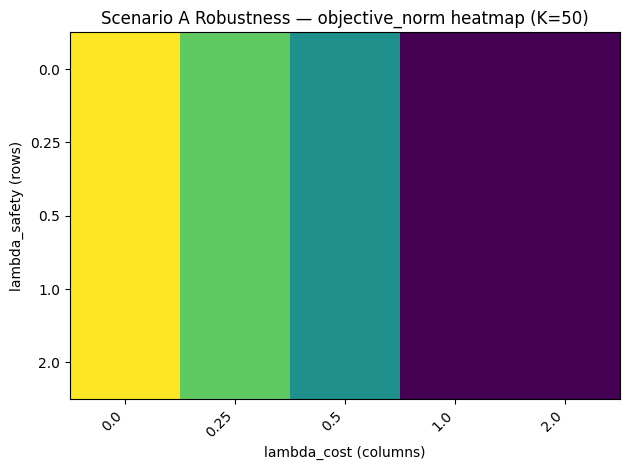

Saved: outputs/figures/05a_objective_heatmap.png


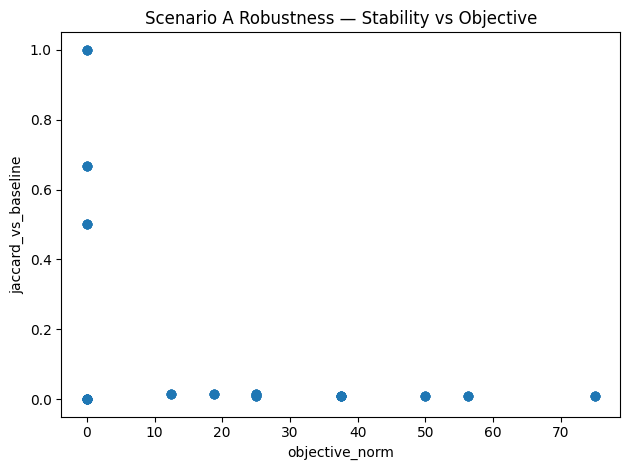

Saved: outputs/figures/05a_jaccard_vs_baseline.png


In [7]:
# ============================================================
# Cell 6 — Figures for robustness reporting
# ============================================================

# --- Objective heatmap for baseline K only (keeps plot readable) ---
K0 = BASELINE["K"]
sub = sweep_df[sweep_df["K"] == K0].copy()

# Pivot into grid for heatmap
pivot_obj = sub.pivot_table(
    index="lambda_safety",
    columns="lambda_cost",
    values="objective_norm",
    aggfunc="mean"
).sort_index(ascending=True)

plt.figure()
plt.imshow(pivot_obj.values, aspect="auto")
plt.title(f"Scenario A Robustness — objective_norm heatmap (K={K0})")
plt.xlabel("lambda_cost (columns)")
plt.ylabel("lambda_safety (rows)")
plt.xticks(range(len(pivot_obj.columns)), [str(c) for c in pivot_obj.columns], rotation=45, ha="right")
plt.yticks(range(len(pivot_obj.index)), [str(r) for r in pivot_obj.index])
plt.tight_layout()
fig1 = FIG_DIR / "05a_objective_heatmap.png"
plt.savefig(fig1, dpi=160)
plt.show()
print("Saved:", fig1)

# --- Jaccard vs baseline scatter, all K ---
plt.figure()
plt.scatter(sweep_df["objective_norm"], sweep_df["jaccard_vs_baseline"])
plt.title("Scenario A Robustness — Stability vs Objective")
plt.xlabel("objective_norm")
plt.ylabel("jaccard_vs_baseline")
plt.tight_layout()
fig2 = FIG_DIR / "05a_jaccard_vs_baseline.png"
plt.savefig(fig2, dpi=160)
plt.show()
print("Saved:", fig2)


### What Cell 6 Just Did

This cell produced the first set of **Phase 5 robustness** visuals and saved them as reusable artifacts.

- **Objective heatmap (fixed K):** It filtered the sweep results to a single portfolio size `K` (baseline `K` if available, otherwise a sensible fallback) and pivoted the grid of `lambda_cost` (columns) × `lambda_safety` (rows) to visualize how `objective_norm` changes across weight settings. It then saved the heatmap to `FIG_DIR / "05a_objective_heatmap.png"`.

- **Stability vs performance scatter (all K):** It plotted `objective_norm` (x-axis) against `jaccard_vs_baseline` (y-axis) to show the tradeoff between higher objective values and how similar each configuration’s selected trial set is to the baseline selection. It saved this scatter to `FIG_DIR / "05a_jaccard_vs_baseline.png"`.

These figures help quickly spot **robust regions** (good objective with high selection stability) versus **sensitive regions** (objective gains but big shifts in selected trials).


## Notebook Summary — Phase 5 Robustness Sweeps

In this notebook, we evaluated how sensitive Scenario A selections are to changes in key hyperparameters (portfolio size `K`, `lambda_cost`, and `lambda_safety`). We ran a structured sweep, collected the selected trial sets and objective values, and then quantified **stability** by comparing each configuration’s selection to a baseline using **Jaccard similarity**.

**Key artifacts produced**
- `data/results/05a_robustness_sweep_summary.csv` — one row per sweep configuration with parameters, objective metrics, and stability scores.
- `data/results/05a_robustness_top_configs_selected_trials.csv` — trial selections for a small set of best-performing and most-stable configurations (Git-friendly).
- `FIG_DIR/05a_objective_heatmap.png` — objective surface over (`lambda_cost`, `lambda_safety`) for a fixed `K`.
- `FIG_DIR/05a_jaccard_vs_baseline.png` — stability vs performance scatter across the full sweep.

**How to interpret results**
- Prefer configurations that sit in the upper-right of the stability vs performance plot: **high `objective_norm`** with **high `jaccard_vs_baseline`**.
- If the heatmap shows a wide plateau of strong objectives, the model is robust; if it has sharp peaks, results are more sensitive to weights.

**Next steps**
1. Pick a “robust” configuration (or small band of configs) and freeze it as **Scenario A v1**.
2. Re-run QAOA (local + SV1) on the chosen robust settings and compare to the earlier baseline.
3. Optionally add a second baseline comparison (e.g., compare to classical SA/greedy) using the same stability metrics.
